El impacto de la IA en los estudiantes

Este cuaderno explora patrones en un conjunto de datos de 50.000 estudiantes, investigando cómo el uso de herramientas generativas de IA se relaciona con los resultados académicos y los indicadores psicológicos. Examinamos tres preguntas principales:

¿La dependencia de la IA se correlaciona con la ansiedad por los exámenes?

¿Cómo se relacionan las diferentes variables (nivel de habilidad, horas de uso, cambios de GPA) entre sí?

¿Qué puede revelar el análisis de correlación sobre el impacto académico más amplio de la IA?

## 1. Configuración y Carga de Datos

In [ ]:
import os
import pandas as pd
from google.colab import drive


drive.mount('/content/drive')

NOMBRE_CARPETA_DRIVE = 'DataSet'

PATH_BASE = f'/content/drive/MyDrive/DataSet/'

path_final = os.path.join(PATH_BASE, 'ai_student_impact_dataset (1).csv')

df = pd.read_csv(path_final)
df.head()

Mounted at /content/drive


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## 2. Variables clave 

Antes de sumergirnos en el análisis, reducimos el conjunto de datos a las cuatro columnas más relevantes para nuestras hipótesis principales.

In [2]:
cols_of_interest = ["Major_Category", "Skill_Retention_Score", "Anxiety_Level_During_Exams", "Perceived_AI_Dependency"]
df[cols_of_interest].head()

,Major_Category,Skill_Retention_Score,Anxiety_Level_During_Exams,Perceived_AI_Dependency
0,Humanities,86.44,6,5
1,Medical,69.39,9,3
2,Business,73.93,9,5
3,Business,63.58,2,2
4,STEM,100.00,4,4


## 3. Hipótesis 1 - Dependencia de la IA y ansiedad por los exámenes

Nuestra primera hipótesis es que la gran dependencia de las herramientas de IA puede ser perjudicial en situaciones de alto riesgo en las que esas herramientas no están disponibles, como un examen tradicional. Si esto es cierto, esperaríamos que los estudiantes que se perciben a sí mismos como más dependientes de la IA también informen de una mayor ansiedad por el examen

Para probar esto visualmente, trazamos las dos variables contra otras. Debido a que ambos están en escalas enteras discretas, aplicamos jitter (un pequeño desplazamiento aleatorio) para reducir el overplot y revelar mejor la densidad de los datos

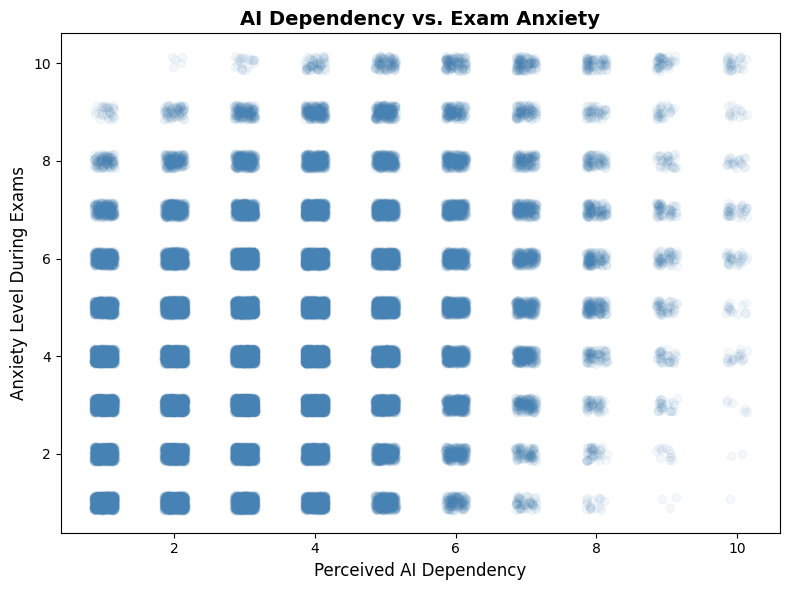

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

x = df ["Perceived_AI_Dependency"]
y = df ["Anxiety_Level_During_Exams"]

x_jitter = x + np.random.uniform(-0.15, 0.15, size=len(x))
y_jitter = y + np.random.uniform(-0.15, 0.15, size=len(y))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x_jitter, y_jitter, alpha=0.05, color="steelblue")
ax.set_xlabel("Perceived AI Dependency", fontsize=12)
ax.set_ylabel("Anxiety Level During Exams", fontsize=12)
ax.set_title("AI Dependency vs. Exam Anxiety", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretación Visual**: Los niveles de ansiedad se extienden a todos los niveles de dependencias. Puede haber una ligera concentración de mayor ansiedad en puntuaciones de dependencias de medias a altas pero la relación no es inmediatamente obvia solo desde el grafico de dispersión. Lo cuantificamos a continuación con la correlación de Pearson.

In [6]:
r = df["Perceived_AI_Dependency"].corr(df["Anxiety_Level_During_Exams"])
print(f"Pearson r (AI Dependency vs. Exam Anxiety): {r:.4f}")

Pearson r (AI Dependency vs. Exam Anxiety): 0.3076


**Resultado**: El coeficiente de correlación **0.31** indica una *débil relación positiva* entre la dependencia percibida de la IA y la ansiedad ante los exámenes. Si bien es estadisticamente significativo en un conjunto de datos tan grande, el tamaño de la IA explica una porción relativamente pequeña de la varianza en la ansiedad.

## 4. Análisis de correlación más amplio

A continuación, ampliamos nuestra perspectiva para explorar como se relacionan simultáneamente múltiples variables. Desarrollaremos dos caracteristicas adicionales más:

> **Cambio de Promedio**: La diferencia entre el promedio de calificaciones posterior y anterior al semestre, que sirve como medida directa del progreso académico.


> **Valor de la habilidad de ingenieria del mensaje**: Una calificación ordinal de la categoría (Principiante: 1, Intermedio: 2, Avanzado: 3).

In [7]:
df["Gpa_Change"] = df["Post_Semester_GPA"] - df["Pre_Semester_GPA"]

skill_map = {"Beginner": 1, "Intermediate": 2, "Advanced": 3}
df["Prompt_Engineering_Skill_Value"] = df["Prompt_Engineering_Skill"].map(skill_map)

print(df[["Prompt_Engineering_Skill", "Prompt_Engineering_Skill_Value"]].drop_duplicates().sort_values("Prompt_Engineering_Skill_Value"))

  Prompt_Engineering_Skill  Prompt_Engineering_Skill_Value
0                 Beginner                               1
3             Intermediate                               2
1                 Advanced                               3


In [11]:
# Matriz de correlación en variables claves 

df.columns = df.columns.str.strip()

corr_vars = [
    "Prompt_Engineering_Skill_Value",
    "Perceived_AI_Dependency",
    "Skill_Retention_Score",
    "Anxiety_Level_During_Exams",
    "Weekly_GenAI_Hours",
    "Gpa_Change"  
]

corr_matrix = df[corr_vars].corr()
print(corr_matrix.round(3))

                                Prompt_Engineering_Skill_Value  \
Prompt_Engineering_Skill_Value                           1.000   
Perceived_AI_Dependency                                  0.007   
Skill_Retention_Score                                    0.327   
Anxiety_Level_During_Exams                               0.003   
Weekly_GenAI_Hours                                       0.019   
Gpa_Change                                               0.127   

                                Perceived_AI_Dependency  \
Prompt_Engineering_Skill_Value                    0.007   
Perceived_AI_Dependency                           1.000   
Skill_Retention_Score                            -0.084   
Anxiety_Level_During_Exams                        0.308   
Weekly_GenAI_Hours                                0.665   
Gpa_Change                                       -0.039   

                                Skill_Retention_Score  \
Prompt_Engineering_Skill_Value                  0.327   
Perceived

## 5. Conclusiones Claves

La matriz de correlación completa revela varios patrones notables:

| Pair | Interpretation |
| :--- | :--- |
| **Weekly GenAI Hours ↔ Perceived AI Dependency** | **0.67** <br> Strong positive: more hours → stronger sense of dependency |
| **Prompt Engineering Skill ↔ Skill Retention Score** | **0.33** <br> Moderate positive: better prompt skills → better retention |
| **Perceived AI Dependency ↔ Anxiety** | **0.31** <br> Weak positive: supports Hypothesis 1 |
| **Weekly GenAI Hours ↔ Anxiety** | **0.27** <br> Weak positive: more AI use → slightly higher exam anxiety |
| **Prompt Engineering Skill ↔ GPA Change** | **0.13** <br> Weak positive: skilled users see slightly higher GPA gains |
| **Perceived AI Dependency ↔ GPA Change** | **−0.04** <br> Near zero: dependency does not meaningfully hurt grades |

**Resumen**: El conjunto de datos ofrece una perspectiva matizada. Si bien la dependencia y el uso intensivo de la IA se asocian con una ansiedad moderadamente elevada ante los exámenes, la rápida adquisición de competencias en ingenieria parece tener un efecto protector, correlacionándose con una mejor rertención de habilidades y un mayor promedio de calificaciones. Esto sugiere que la forma en que los estudiantes interactúan con la IA es más importante que la cantidad de veces que la utilizan.

## 6. EDA

Dataset Shape : (50000, 18)

Columns:
 Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level', 'Gpa_Change',
       'Prompt_Engineering_Skill_Value'],
      dtype='object')

Data Types:

Student_ID                          int64
Major_Category                     object
Year_of_Study                      object
Pre_Semester_GPA                  float64
Weekly_GenAI_Hours                float64
Primary_Use_Case                   object
Prompt_Engineering_Skill           object
Tool_Diversity                      int64
Paid_Subscription                    bool
Traditional_Study_Hours           float64
Perceived_AI_Dependency             int64
Institution

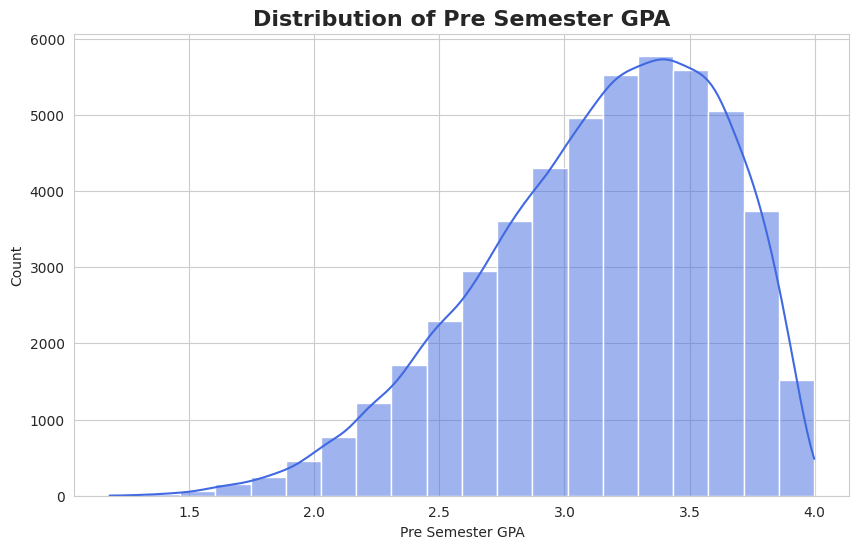

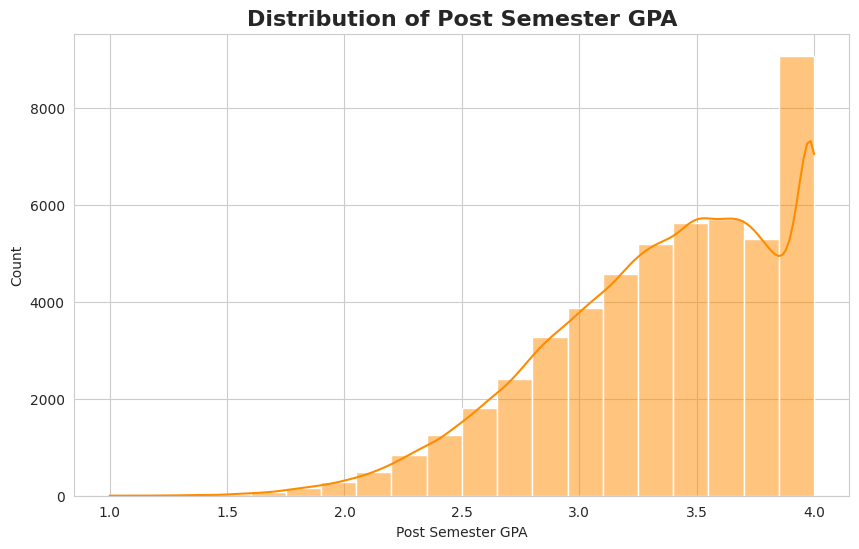

/tmp/ipykernel_8102/305188451.py:59: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




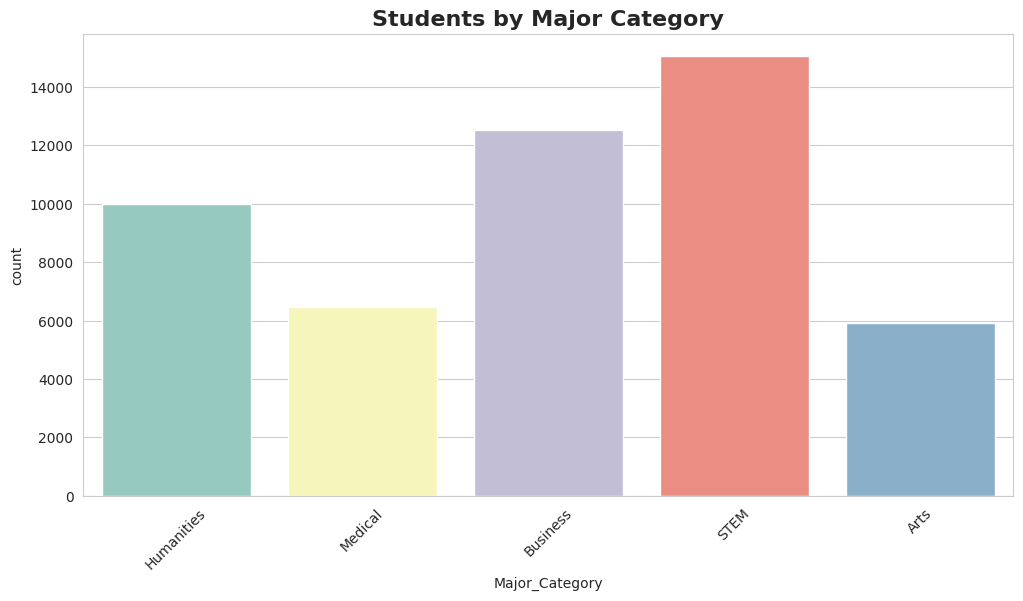

/tmp/ipykernel_8102/305188451.py:74: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




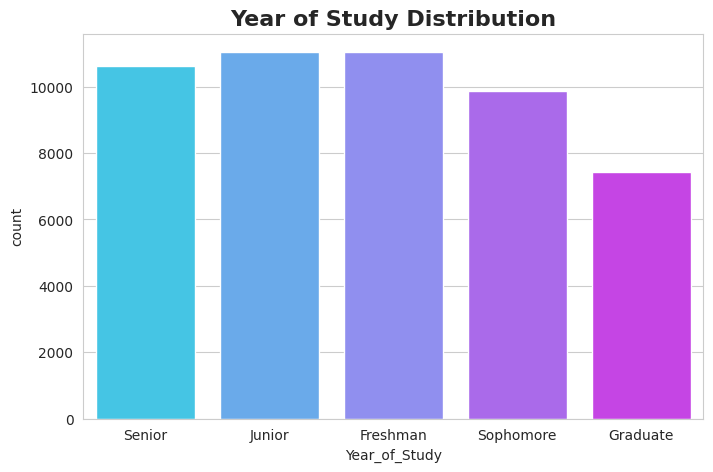

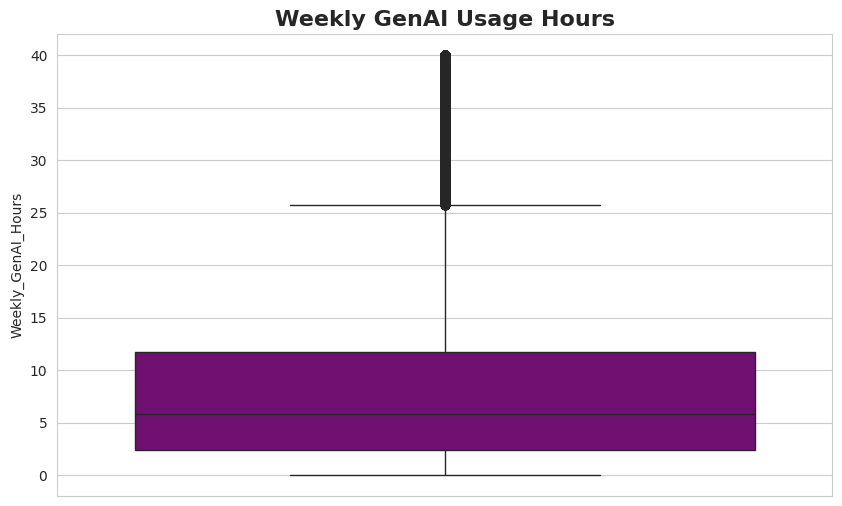

/tmp/ipykernel_8102/305188451.py:102: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




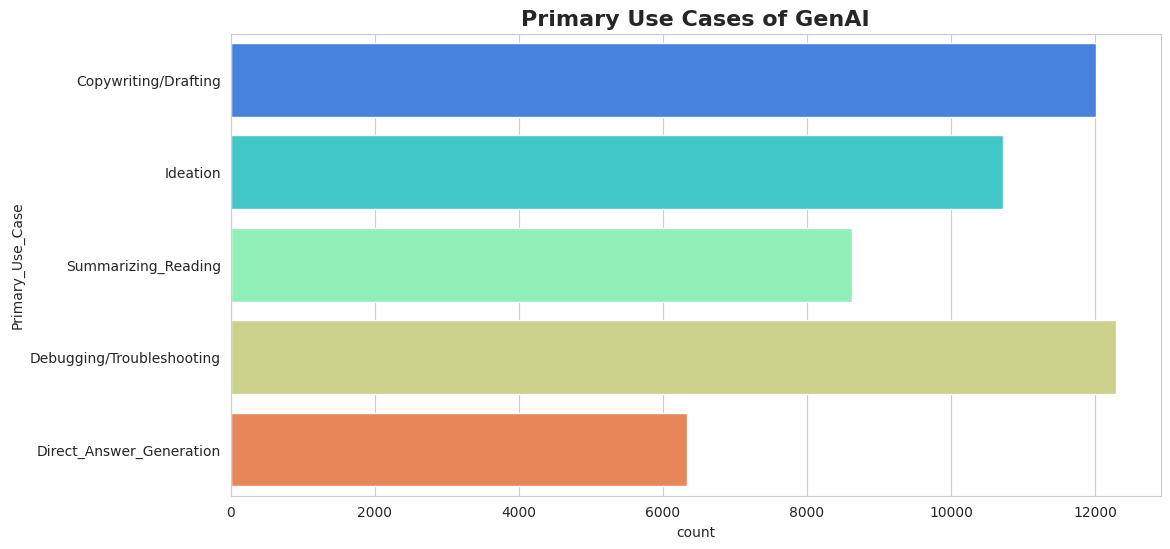

/tmp/ipykernel_8102/305188451.py:116: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




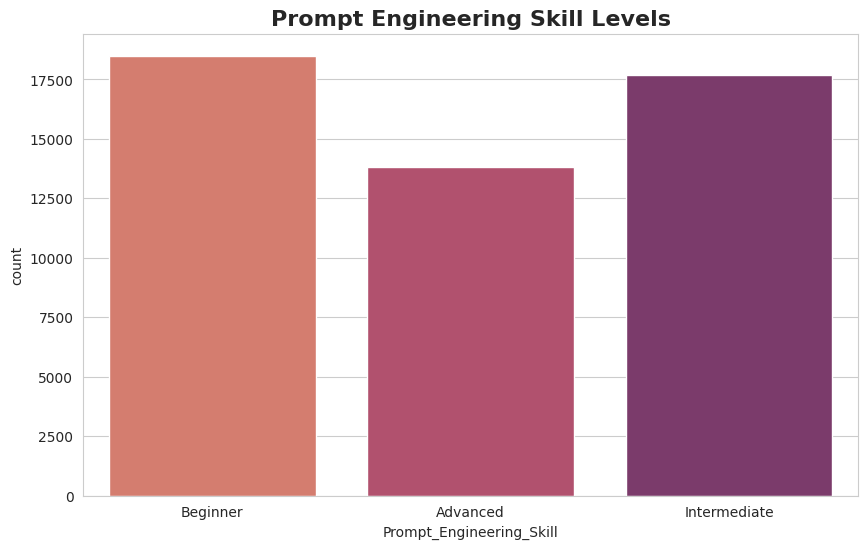

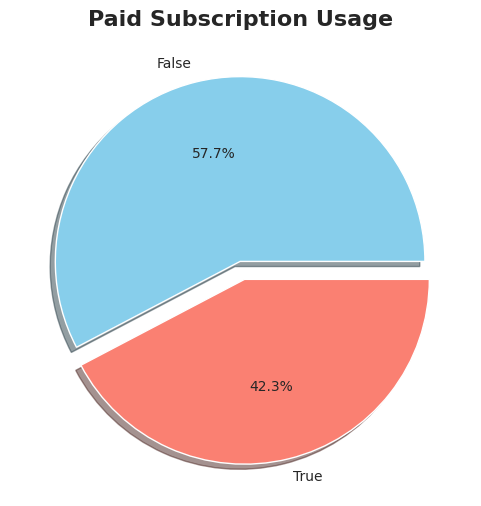

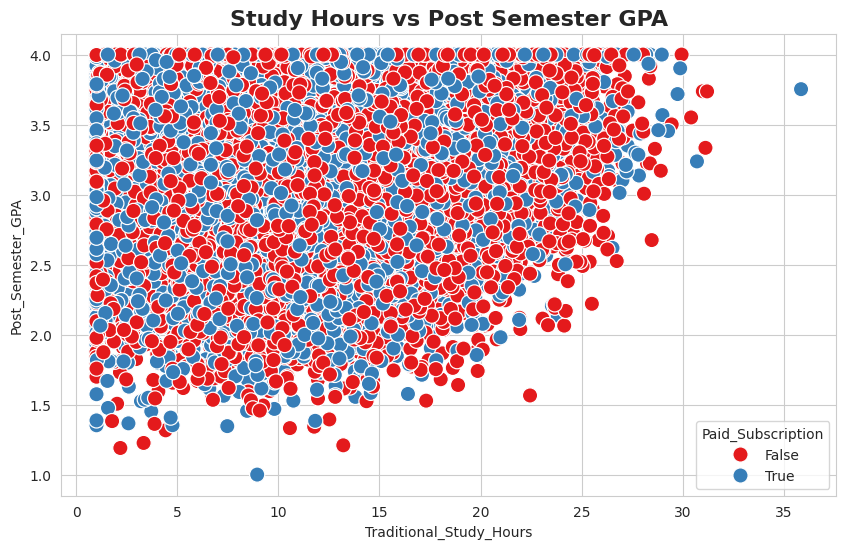

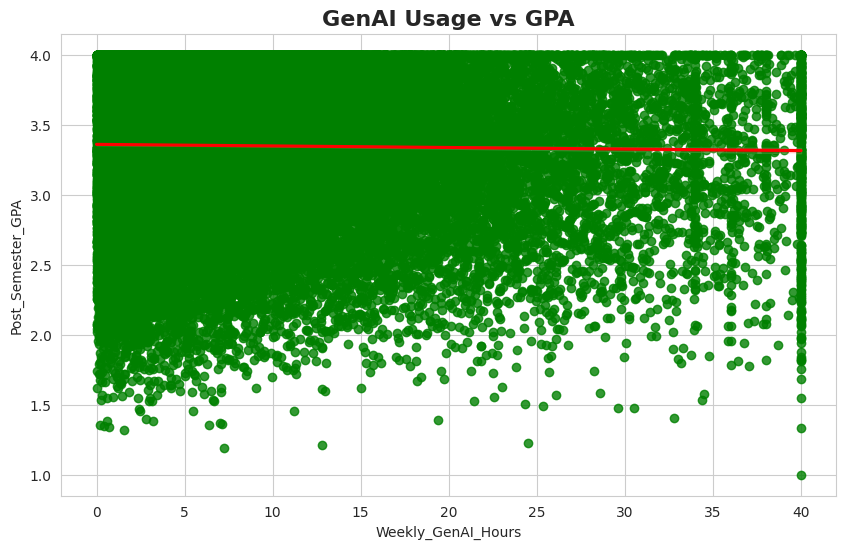

/tmp/ipykernel_8102/305188451.py:182: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




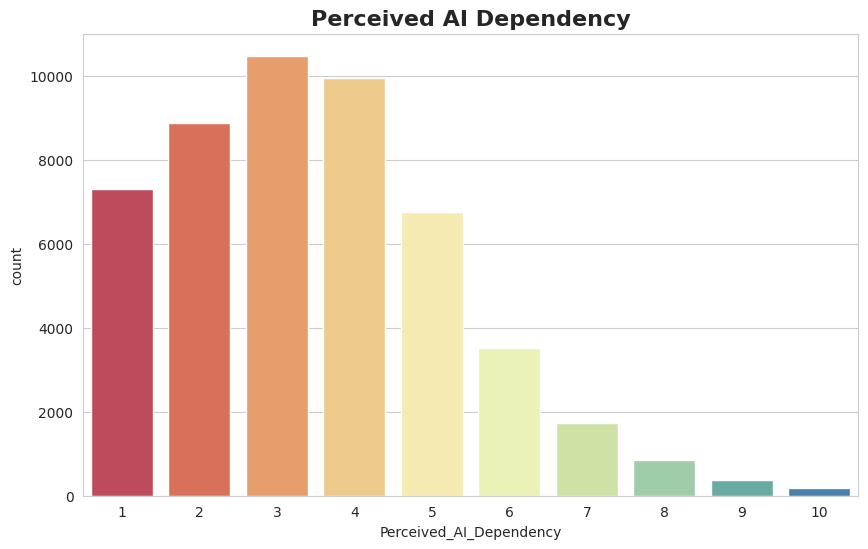

/tmp/ipykernel_8102/305188451.py:196: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




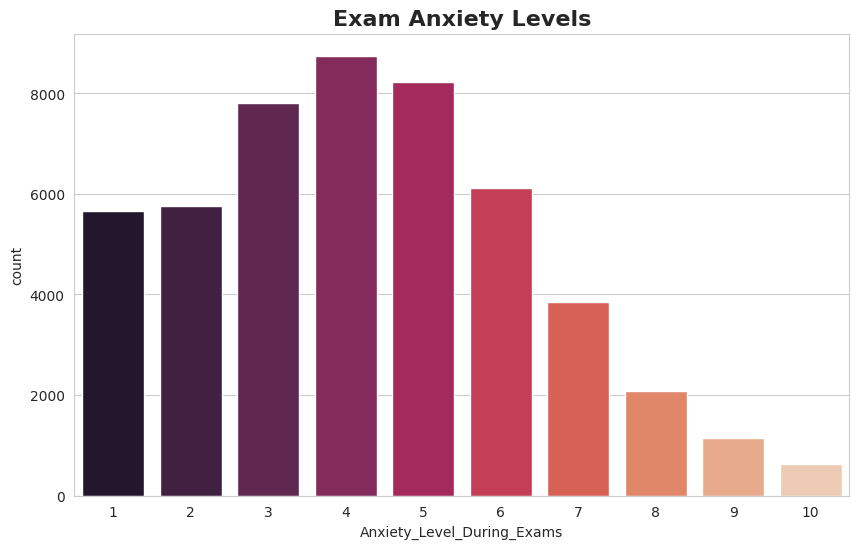

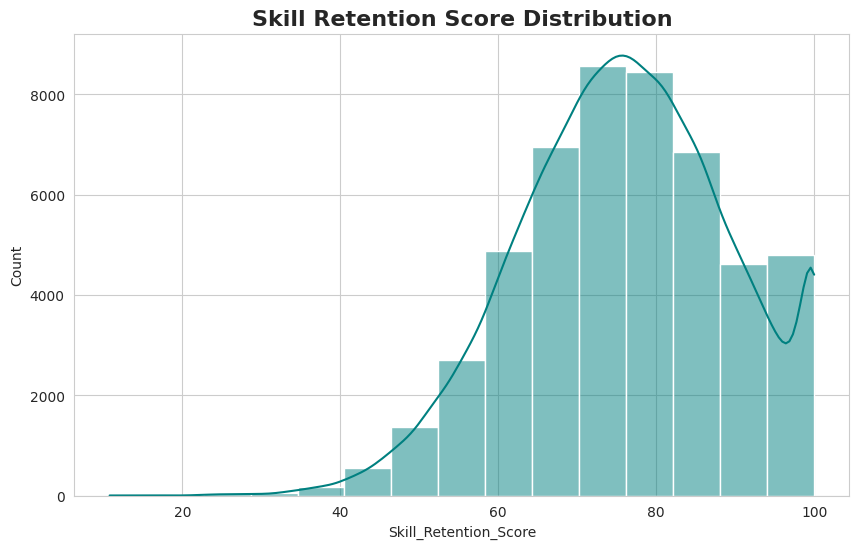

/tmp/ipykernel_8102/305188451.py:225: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




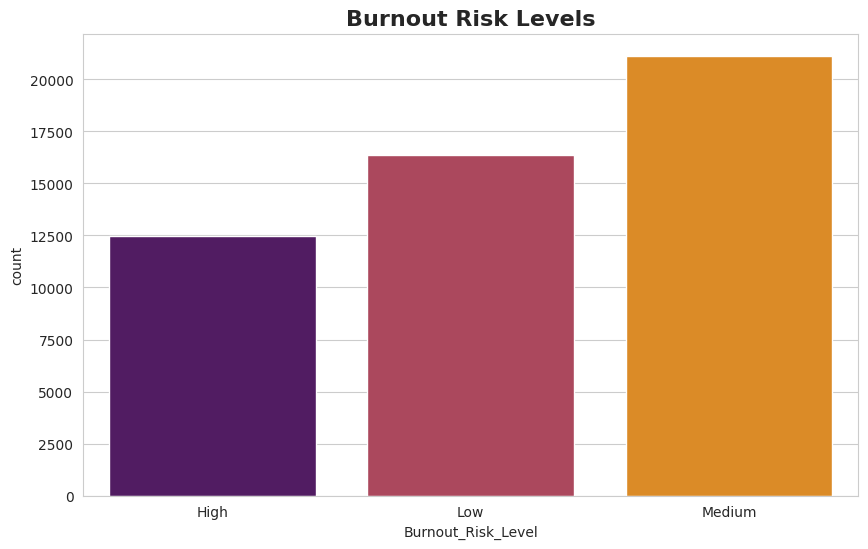

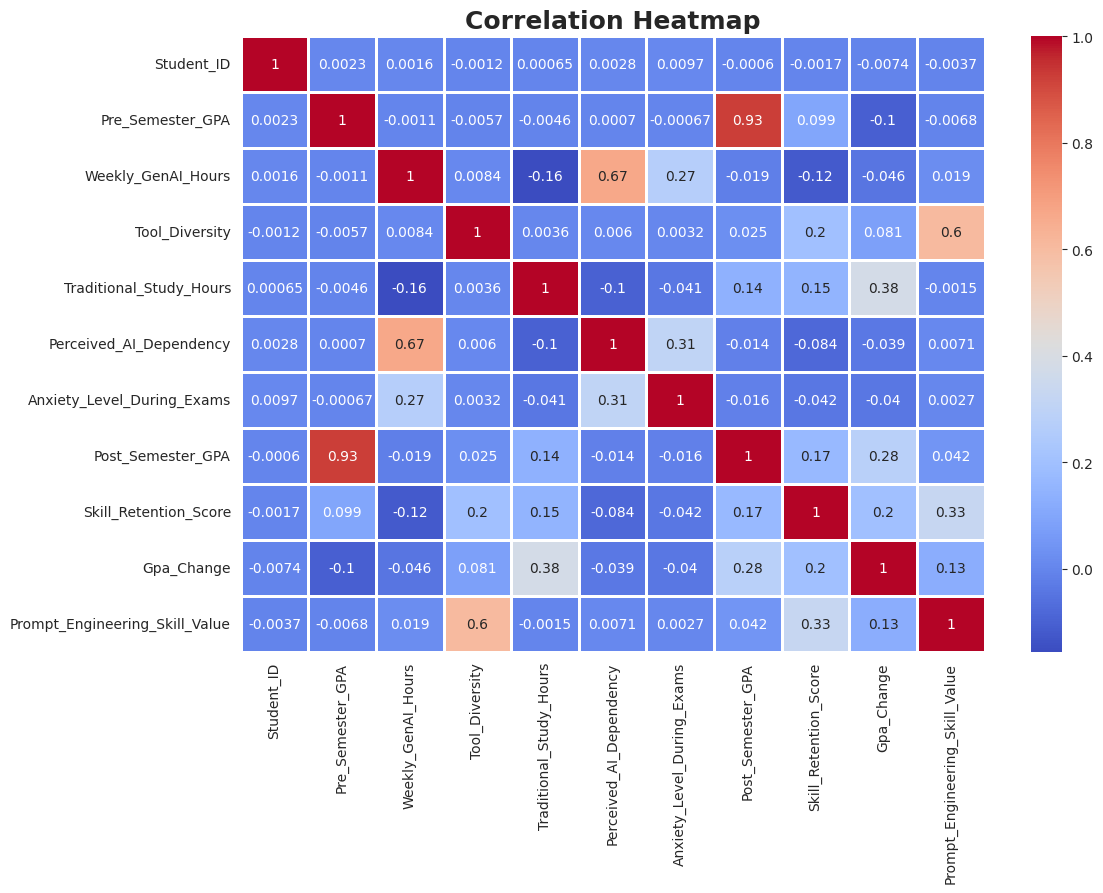

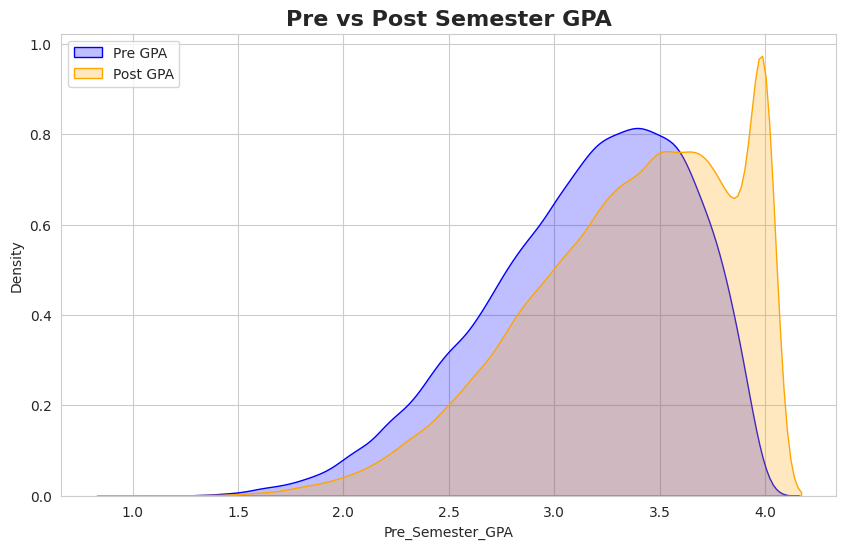

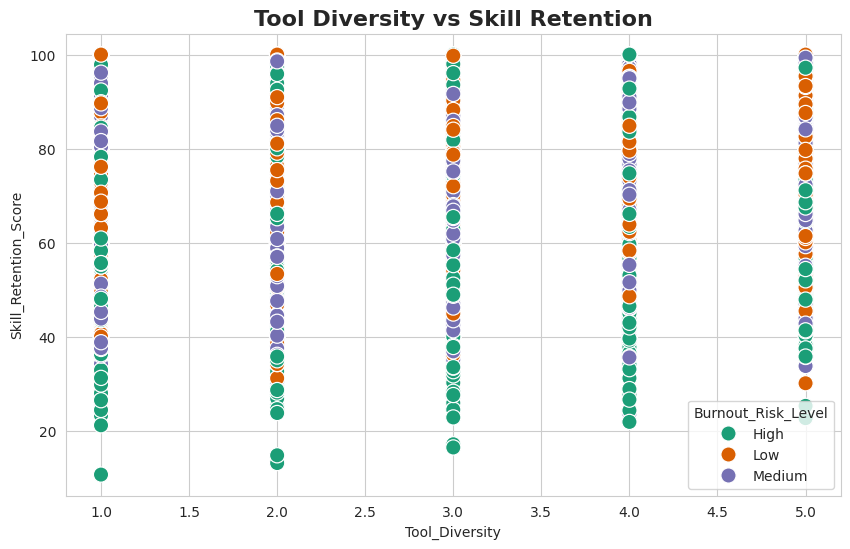

/tmp/ipykernel_8102/305188451.py:298: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




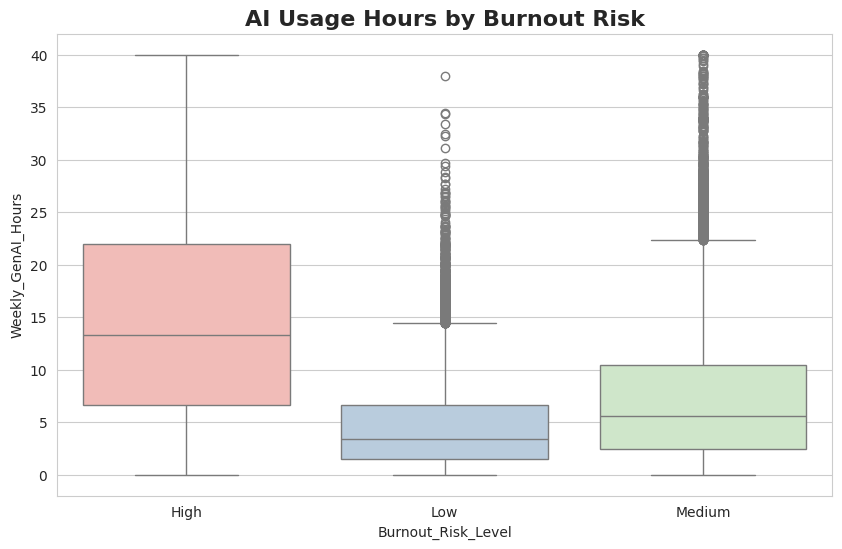

/tmp/ipykernel_8102/305188451.py:342: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




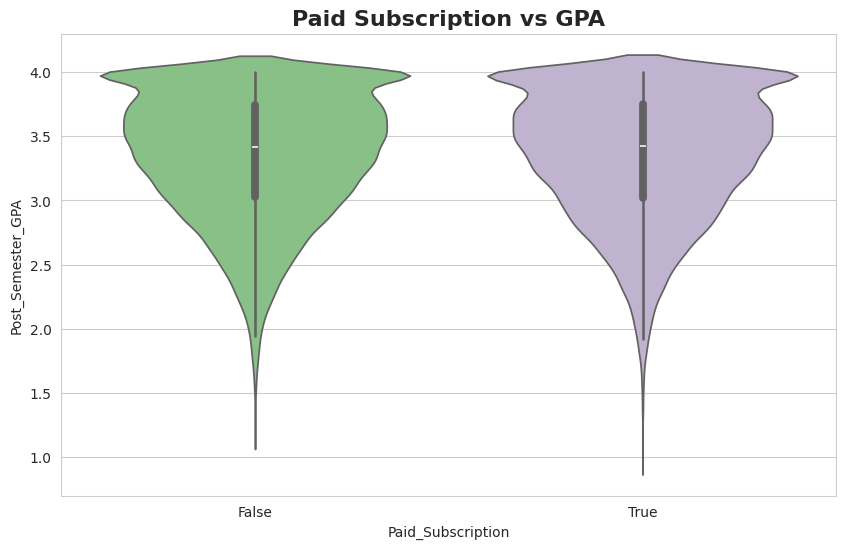

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has b

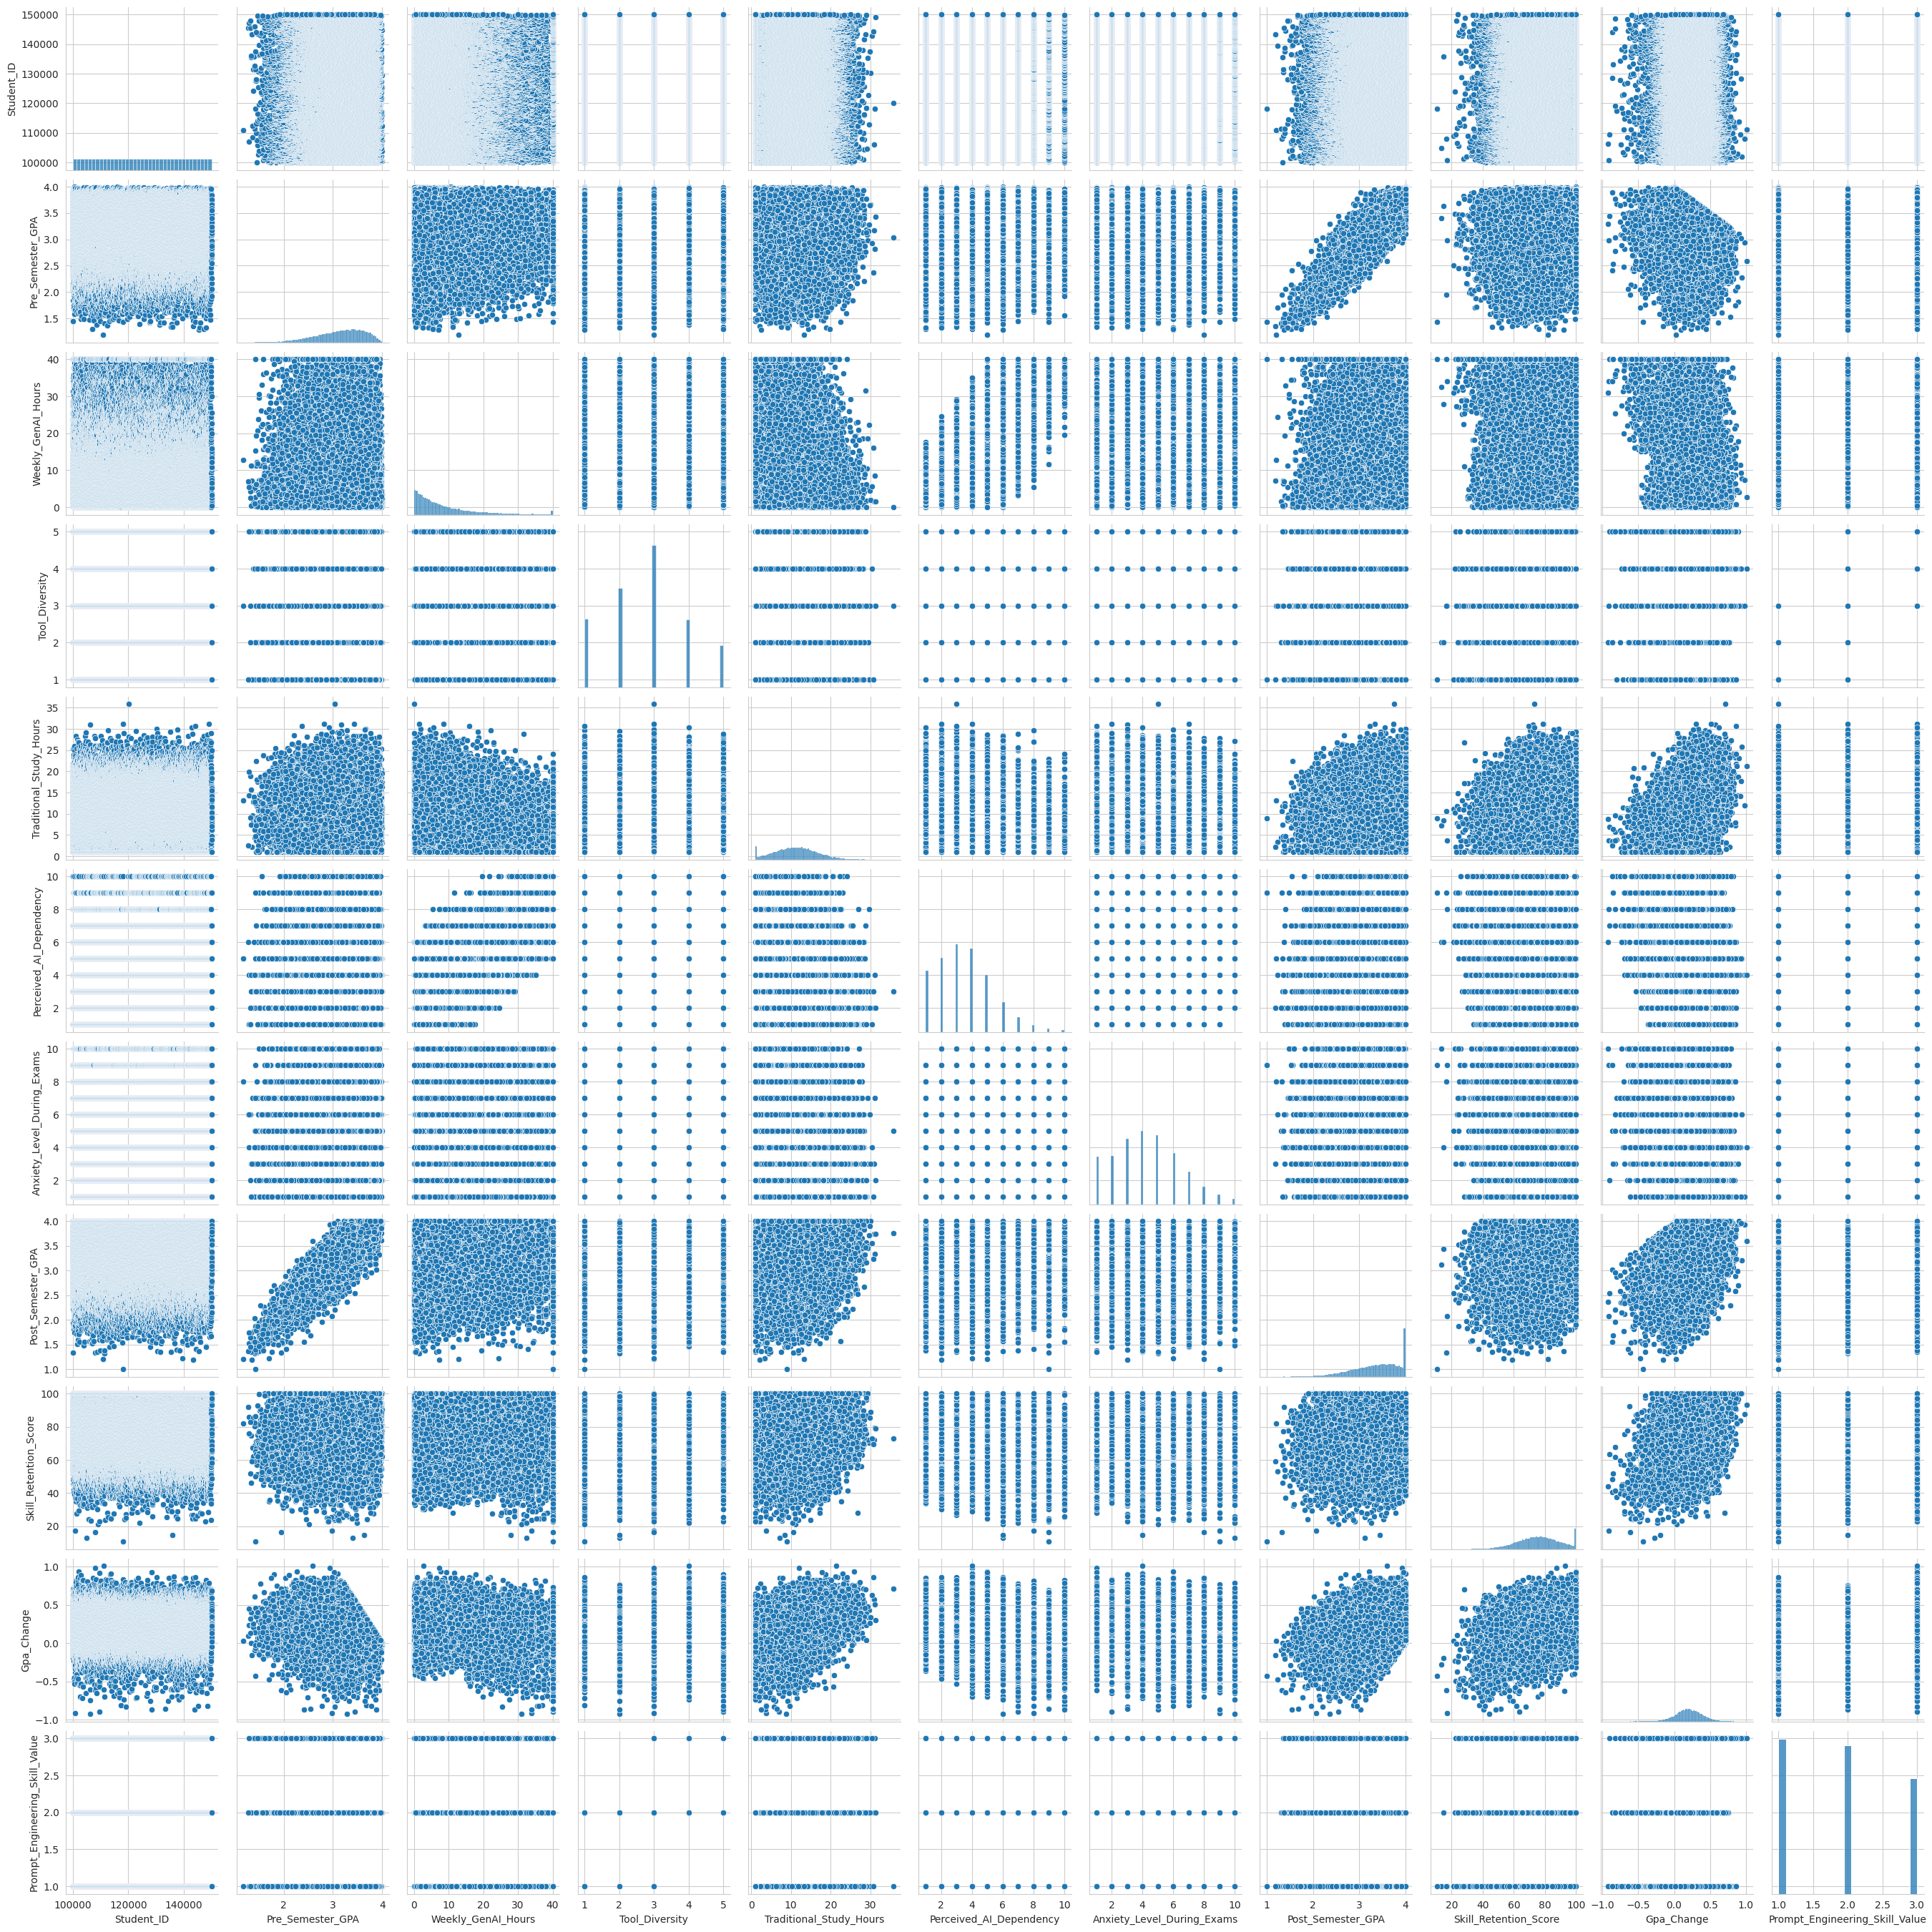

/tmp/ipykernel_8102/305188451.py:368: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




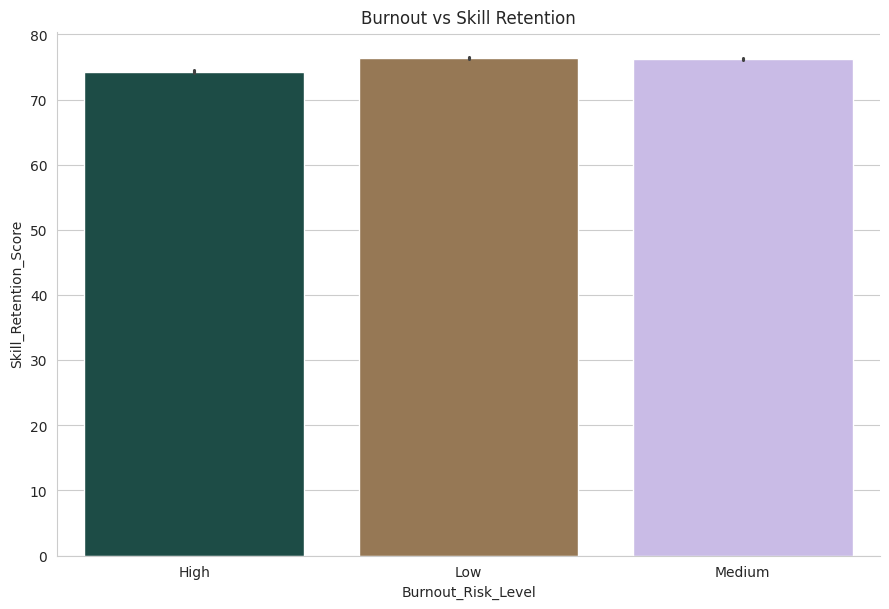

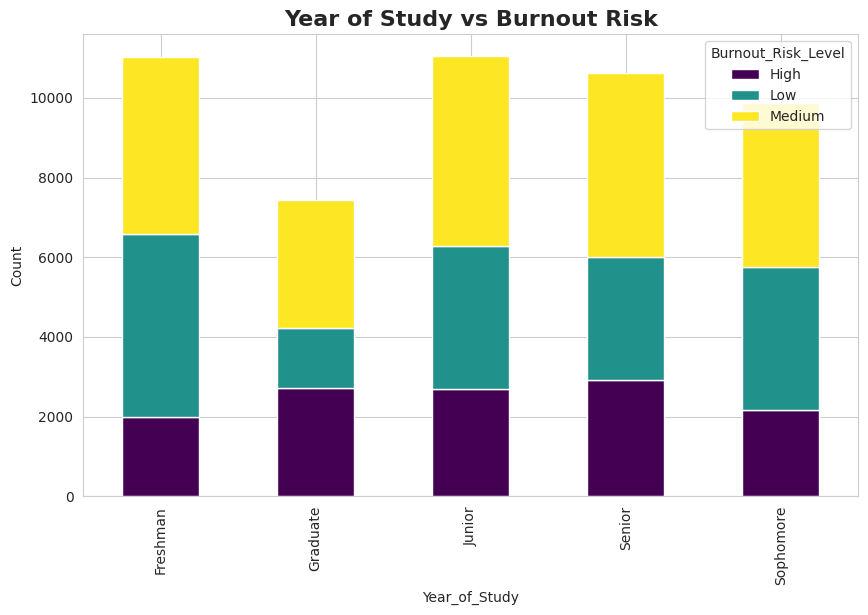


Visualization Completed Successfully!
Total Columns Visualized : 18


In [12]:
import plotly.express as px
import seaborn as sns

# =======================
# BASIC INFORMATION
# =======================

print("Dataset Shape :", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n")
print(df.dtypes)

# =========================
# STYLE SETTINGS
# =========================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# =========================
# COLOR PALETTES
# =========================
palette1 = "viridis"
palette2 = "magma"
palette3 = "coolwarm"
palette4 = "Set2"
palette5 = "plasma"

# ============================================================
# 1. DISTRIBUTION OF PRE-SEMESTER GPA
# ============================================================
plt.figure(figsize=(10,6))
sns.histplot(df['Pre_Semester_GPA'], bins=20,
             kde=True, color='royalblue')
plt.title("Distribution of Pre Semester GPA",
          fontsize=16, fontweight='bold')
plt.xlabel("Pre Semester GPA")
plt.ylabel("Count")
plt.show()

# ============================================================
# 2. DISTRIBUTION OF POST-SEMESTER GPA
# ============================================================
plt.figure(figsize=(10,6))
sns.histplot(df['Post_Semester_GPA'],
             bins=20,
             kde=True,
             color='darkorange')
plt.title("Distribution of Post Semester GPA",
          fontsize=16,
          fontweight='bold')
plt.xlabel("Post Semester GPA")
plt.ylabel("Count")
plt.show()

# ============================================================
# 3. MAJOR CATEGORY COUNT
# ============================================================
plt.figure(figsize=(12,6))
sns.countplot(data=df,
              x='Major_Category',
              palette='Set3')

plt.title("Students by Major Category",
          fontsize=16,
          fontweight='bold')

plt.xticks(rotation=45)
plt.show()

# ============================================================
# 4. YEAR OF STUDY DISTRIBUTION
# ============================================================
plt.figure(figsize=(8,5))
sns.countplot(data=df,
              x='Year_of_Study',
              palette='cool')

plt.title("Year of Study Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 5. WEEKLY GENAI HOURS
# ============================================================
plt.figure(figsize=(10,6))
sns.boxplot(data=df,
            y='Weekly_GenAI_Hours',
            color='purple')

plt.title("Weekly GenAI Usage Hours",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 6. PRIMARY USE CASE ANALYSIS
# ============================================================
plt.figure(figsize=(12,6))
sns.countplot(data=df,
              y='Primary_Use_Case',
              palette='rainbow')

plt.title("Primary Use Cases of GenAI",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 7. PROMPT ENGINEERING SKILL LEVEL
# ============================================================
plt.figure(figsize=(10,6))
sns.countplot(data=df,
              x='Prompt_Engineering_Skill',
              palette='flare')

plt.title("Prompt Engineering Skill Levels",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 8. PAID SUBSCRIPTION ANALYSIS
# ============================================================
plt.figure(figsize=(6,6))

df['Paid_Subscription'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['skyblue', 'salmon'],
    explode=[0.02, 0.08],
    shadow=True
)

plt.title("Paid Subscription Usage",
          fontsize=16,
          fontweight='bold')

plt.ylabel("")
plt.show()

# ============================================================
# 9. STUDY HOURS VS POST GPA
# ============================================================
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,
                x='Traditional_Study_Hours',
                y='Post_Semester_GPA',
                hue='Paid_Subscription',
                palette='Set1',
                s=120)

plt.title("Study Hours vs Post Semester GPA",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 10. GENAI HOURS VS GPA
# ============================================================
plt.figure(figsize=(10,6))
sns.regplot(data=df,
            x='Weekly_GenAI_Hours',
            y='Post_Semester_GPA',
            scatter_kws={'color':'green'},
            line_kws={'color':'red'})

plt.title("GenAI Usage vs GPA",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 11. AI DEPENDENCY LEVEL
# ============================================================
plt.figure(figsize=(10,6))
sns.countplot(data=df,
              x='Perceived_AI_Dependency',
              palette='Spectral')

plt.title("Perceived AI Dependency",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 12. EXAM ANXIETY LEVEL
# ============================================================
plt.figure(figsize=(10,6))
sns.countplot(data=df,
              x='Anxiety_Level_During_Exams',
              palette='rocket')

plt.title("Exam Anxiety Levels",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 13. SKILL RETENTION SCORE DISTRIBUTION
# ============================================================
plt.figure(figsize=(10,6))
sns.histplot(df['Skill_Retention_Score'],
             bins=15,
             kde=True,
             color='teal')

plt.title("Skill Retention Score Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 14. BURNOUT RISK LEVEL
# ============================================================
plt.figure(figsize=(10,6))
sns.countplot(data=df,
              x='Burnout_Risk_Level',
              palette='inferno')

plt.title("Burnout Risk Levels",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 15. CORRELATION HEATMAP
# ============================================================
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap='coolwarm',
            linewidths=1)

plt.title("Correlation Heatmap",
          fontsize=18,
          fontweight='bold')

plt.show()

# ============================================================
# 16. GPA COMPARISON BEFORE & AFTER
# ============================================================
plt.figure(figsize=(10,6))

sns.kdeplot(df['Pre_Semester_GPA'],
            fill=True,
            color='blue',
            label='Pre GPA')

sns.kdeplot(df['Post_Semester_GPA'],
            fill=True,
            color='orange',
            label='Post GPA')

plt.title("Pre vs Post Semester GPA",
          fontsize=16,
          fontweight='bold')

plt.legend()
plt.show()

# ============================================================
# 17. TOOL DIVERSITY VS SKILL RETENTION
# ============================================================
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x='Tool_Diversity',
                y='Skill_Retention_Score',
                hue='Burnout_Risk_Level',
                palette='Dark2',
                s=120)

plt.title("Tool Diversity vs Skill Retention",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 18. BOXPLOT : AI HOURS BY BURNOUT RISK
# ============================================================
plt.figure(figsize=(10,6))

sns.boxplot(data=df,
            x='Burnout_Risk_Level',
            y='Weekly_GenAI_Hours',
            palette='Pastel1')

plt.title("AI Usage Hours by Burnout Risk",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 19. INTERACTIVE PLOTLY SCATTER
# ============================================================
fig = px.scatter(
    df,
    x='Weekly_GenAI_Hours',
    y='Post_Semester_GPA',
    color='Burnout_Risk_Level',
    size='Tool_Diversity',
    hover_data=['Major_Category'],
    title='Interactive AI Usage vs GPA'
)

fig.show()

# ============================================================
# 20. INTERACTIVE SUNBURST CHART
# ============================================================
fig2 = px.sunburst(
    df,
    path=['Major_Category',
          'Primary_Use_Case',
          'Burnout_Risk_Level'],
    title='Student AI Usage Hierarchy'
)

fig2.show()

# ============================================================
# 21. VIOLIN PLOT
# ============================================================
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='Paid_Subscription',
    y='Post_Semester_GPA',
    palette='Accent'
)

plt.title("Paid Subscription vs GPA",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 22. PAIRPLOT
# ============================================================
sns.pairplot(
    df[numeric_cols.columns],
    palette='husl'
)

plt.show()

# ============================================================
# 23. CATPLOT
# ============================================================
sns.catplot(
    data=df,
    x='Burnout_Risk_Level',
    y='Skill_Retention_Score',
    kind='bar',
    palette='cubehelix',
    height=6,
    aspect=1.5
)

plt.title("Burnout vs Skill Retention")
plt.show()

# ============================================================
# 24. STACKED BAR CHART
# ============================================================
cross_tab = pd.crosstab(
    df['Year_of_Study'],
    df['Burnout_Risk_Level']
)

cross_tab.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='viridis'
)

plt.title("Year of Study vs Burnout Risk",
          fontsize=16,
          fontweight='bold')

plt.ylabel("Count")
plt.show()

# ============================================================
# 25. FINAL SUMMARY
# ============================================================
print("\nVisualization Completed Successfully!")
print("Total Columns Visualized :", len(df.columns))

## 7. Ingeniería de Caracteristicas 

Dataset Shape : (50000, 18)

Encoded Target Classes:
['High' 'Low' 'Medium']

Training Shape : (40000, 16)
Testing Shape : (10000, 16)


MODEL : Logistic Regression

Accuracy : 0.5210

Classification Report:

              precision    recall  f1-score   support

        High       0.67      0.44      0.53      2497
         Low       0.51      0.47      0.49      3274
      Medium       0.48      0.61      0.54      4229

    accuracy                           0.52     10000
   macro avg       0.55      0.51      0.52     10000
weighted avg       0.54      0.52      0.52     10000



<Figure size 1200x800 with 0 Axes>

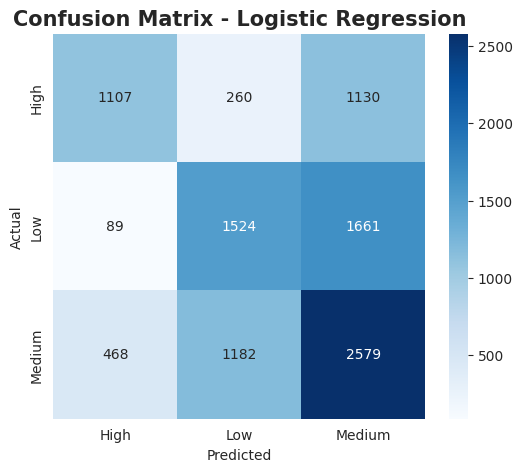


ROC AUC Score : 0.6953


MODEL : Decision Tree

Accuracy : 0.5239

Classification Report:

              precision    recall  f1-score   support

        High       0.67      0.45      0.54      2497
         Low       0.52      0.48      0.50      3274
      Medium       0.48      0.60      0.54      4229

    accuracy                           0.52     10000
   macro avg       0.56      0.51      0.52     10000
weighted avg       0.54      0.52      0.52     10000



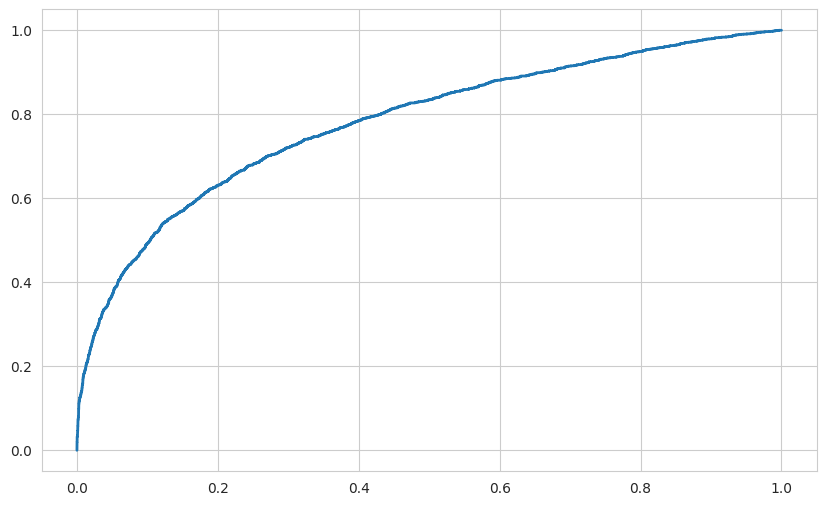

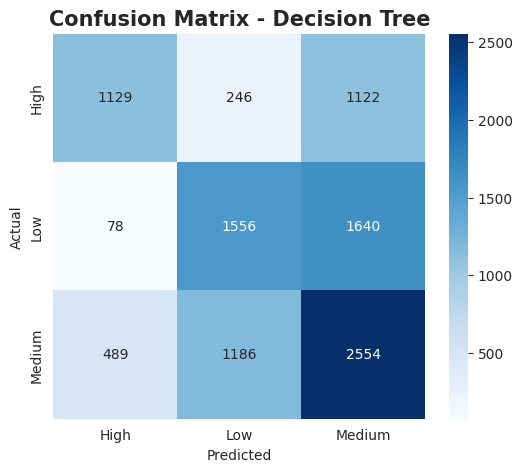


ROC AUC Score : 0.6964


MODEL : Random Forest

Accuracy : 0.5185

Classification Report:

              precision    recall  f1-score   support

        High       0.65      0.47      0.54      2497
         Low       0.51      0.48      0.49      3274
      Medium       0.48      0.58      0.52      4229

    accuracy                           0.52     10000
   macro avg       0.55      0.51      0.52     10000
weighted avg       0.53      0.52      0.52     10000



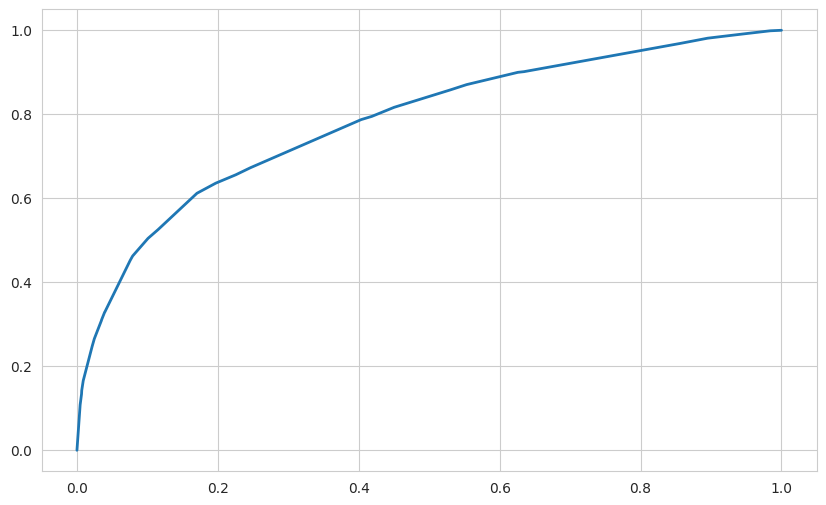

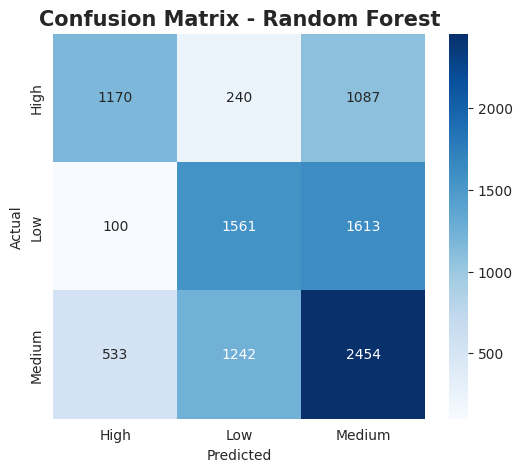


ROC AUC Score : 0.6950


MODEL : KNN

Accuracy : 0.4370

Classification Report:

              precision    recall  f1-score   support

        High       0.46      0.46      0.46      2497
         Low       0.42      0.47      0.44      3274
      Medium       0.44      0.40      0.42      4229

    accuracy                           0.44     10000
   macro avg       0.44      0.44      0.44     10000
weighted avg       0.44      0.44      0.44     10000



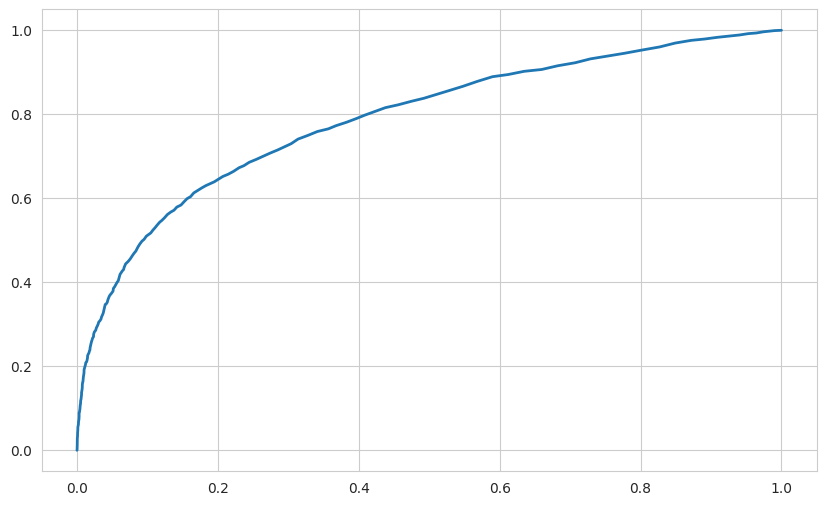

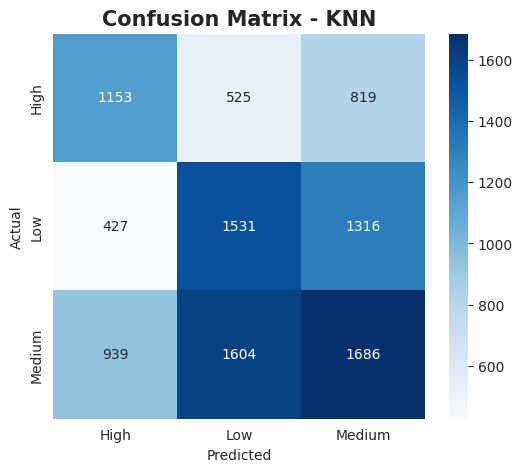


ROC AUC Score : 0.6173


MODEL : SVM

Accuracy : 0.5182

Classification Report:

              precision    recall  f1-score   support

        High       0.71      0.39      0.50      2497
         Low       0.53      0.41      0.46      3274
      Medium       0.47      0.68      0.56      4229

    accuracy                           0.52     10000
   macro avg       0.57      0.49      0.51     10000
weighted avg       0.55      0.52      0.51     10000



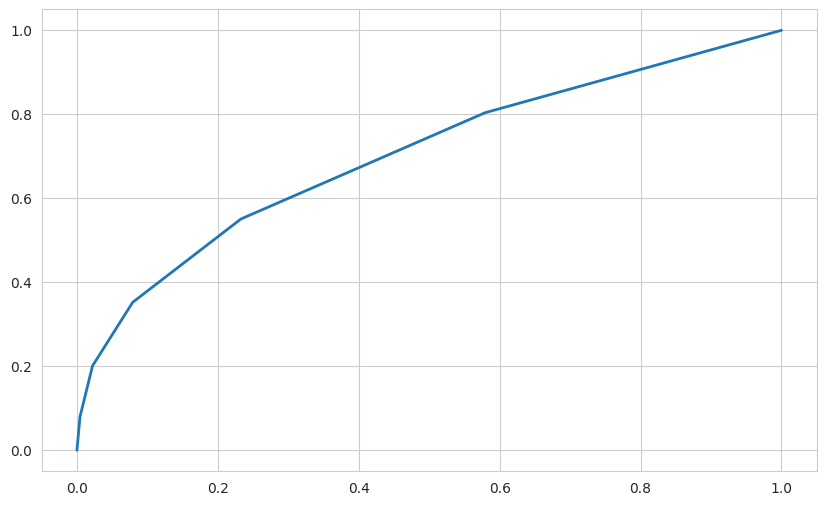

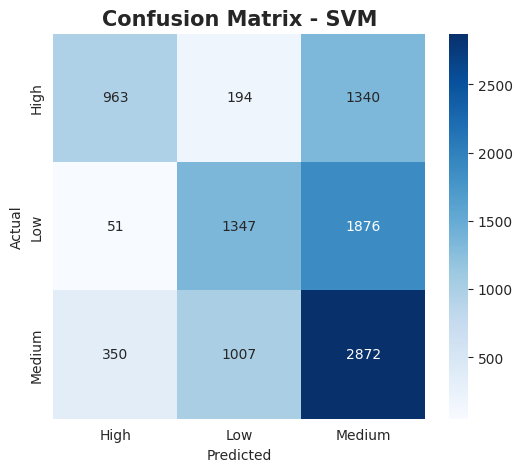


ROC AUC Score : 0.6978


MODEL : Naive Bayes

Accuracy : 0.5059

Classification Report:

              precision    recall  f1-score   support

        High       0.64      0.45      0.53      2497
         Low       0.47      0.70      0.56      3274
      Medium       0.49      0.39      0.43      4229

    accuracy                           0.51     10000
   macro avg       0.53      0.51      0.51     10000
weighted avg       0.52      0.51      0.50     10000



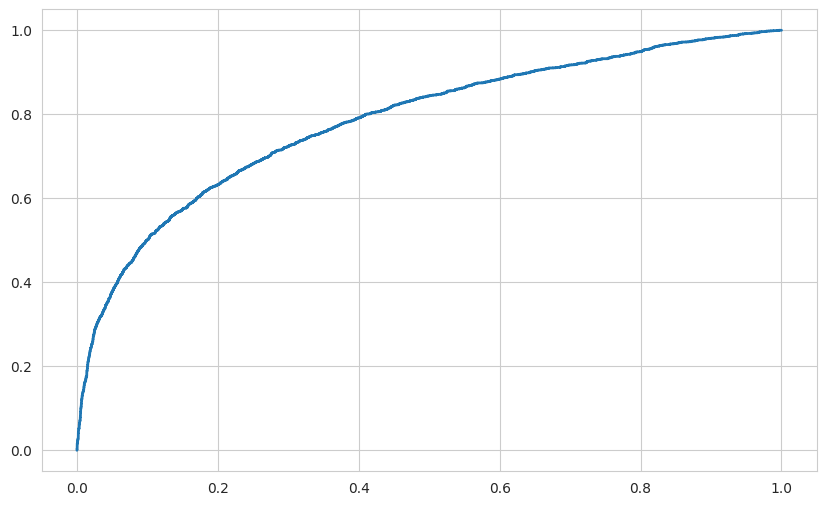

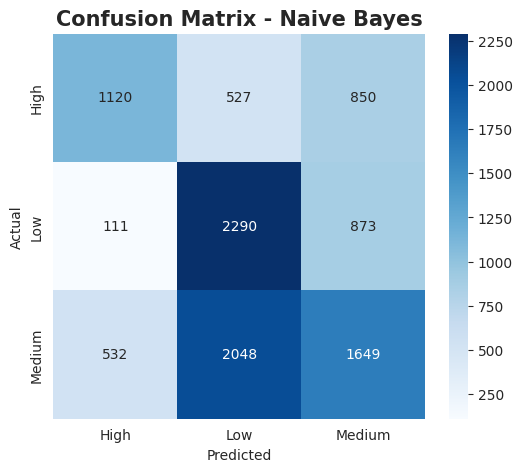


ROC AUC Score : 0.6861


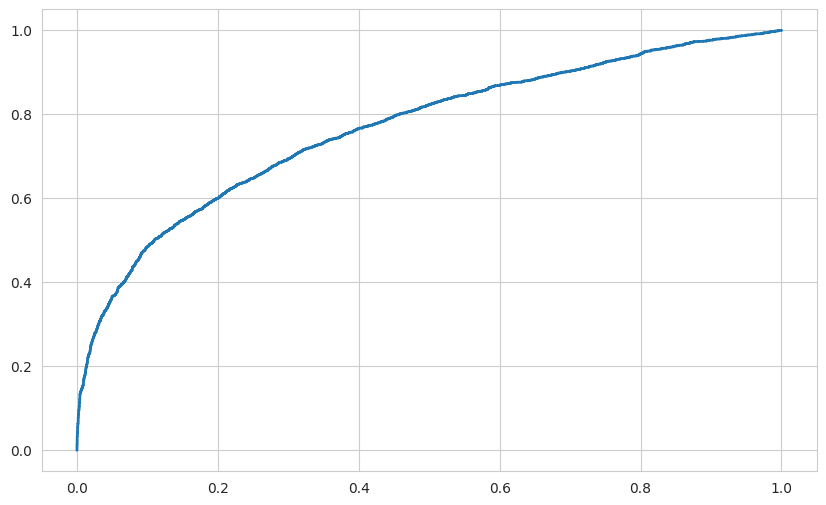

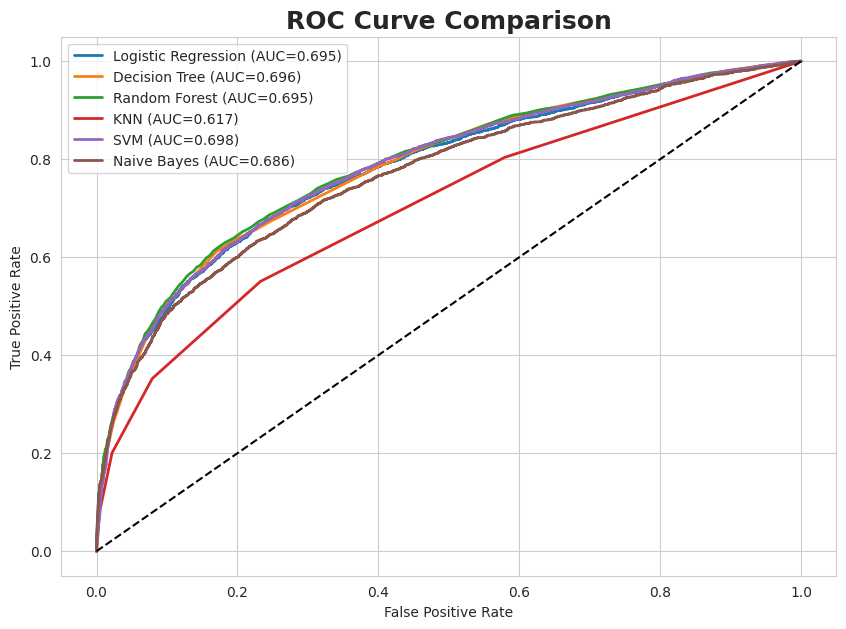



FINAL MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
1        Decision Tree    0.5239  0.696443
0  Logistic Regression    0.5210  0.695284
2        Random Forest    0.5185  0.695024
4                  SVM    0.5182  0.697762
5          Naive Bayes    0.5059  0.686086
3                  KNN    0.4370  0.617288


/tmp/ipykernel_8102/1104365017.py:319: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




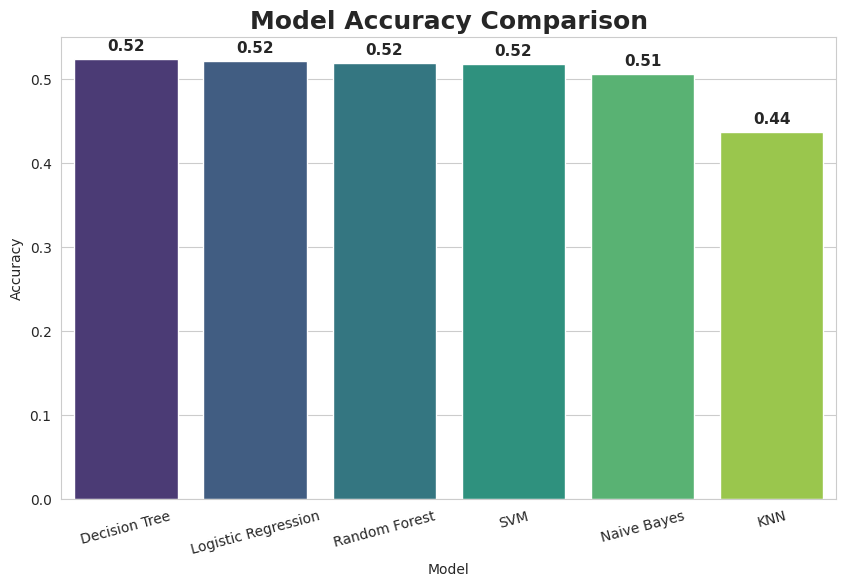


Top Important Features:

                           Feature  Importance
3               Weekly_GenAI_Hours    0.179010
8          Traditional_Study_Hours    0.101317
13           Skill_Retention_Score    0.097591
2                 Pre_Semester_GPA    0.096433
14                      Gpa_Change    0.095637
12               Post_Semester_GPA    0.089211
9          Perceived_AI_Dependency    0.059410
11      Anxiety_Level_During_Exams    0.052686
4                 Primary_Use_Case    0.038463
6                   Tool_Diversity    0.037893
0                   Major_Category    0.037290
1                    Year_of_Study    0.036483
10            Institutional_Policy    0.026886
5         Prompt_Engineering_Skill    0.019120
15  Prompt_Engineering_Skill_Value    0.018834
7                Paid_Subscription    0.013736


/tmp/ipykernel_8102/1104365017.py:372: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




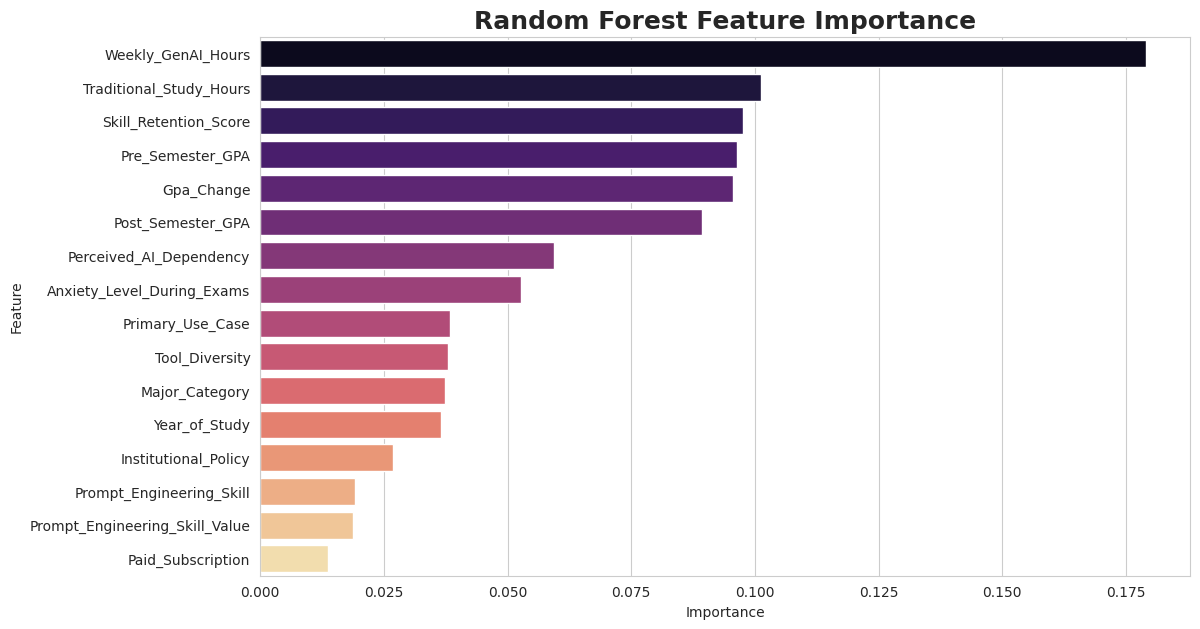



BEST MODEL
Model Name : Decision Tree
Accuracy   : 0.5239
ROC AUC    : 0.6964

Machine Learning Pipeline Completed Successfully!


In [13]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


print("Dataset Shape :", df.shape)

df = df.drop("Student_ID", axis=1)

# ==========================================================
# TARGET COLUMN
# ==========================================================
# We will predict Burnout Risk Level

target_column = "Burnout_Risk_Level"

X = df.drop(target_column, axis=1)
y = df[target_column]

label_encoders = {}

for column in X.columns:
    
    if X[column].dtype == 'object':
        
        le = LabelEncoder()
        
        X[column] = le.fit_transform(X[column])
        
        label_encoders[column] = le

# Encode target separately
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print("\nEncoded Target Classes:")
print(target_encoder.classes_)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

# ==========================================================
# FEATURE SCALING
# ==========================================================
# Fit scaler ONLY on training data
# Prevents data leakage

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ==========================================================
# MACHINE LEARNING MODELS
# ==========================================================
models = {
    
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    
    "KNN": KNeighborsClassifier(n_neighbors=5),
    
    "SVM": SVC(
        probability=True,
        kernel='rbf',
        random_state=42
    ),
    
    "Naive Bayes": GaussianNB()
}

# ==========================================================
# STORE RESULTS
# ==========================================================
results = []

# ==========================================================
# ROC CURVE FIGURE
# ==========================================================
plt.figure(figsize=(12,8))

# ==========================================================
# TRAIN & EVALUATE MODELS
# ==========================================================
for model_name, model in models.items():
    
    print("\n")
    print("="*60)
    print("MODEL :", model_name)
    print("="*60)
    
    # ======================================================
    # TRAIN MODEL
    # ======================================================
    
    # Use scaled data for models sensitive to scaling
    if model_name in ["Logistic Regression", "KNN", "SVM"]:
        
        model.fit(X_train_scaled, y_train)
        
        y_pred = model.predict(X_test_scaled)
        
        y_prob = model.predict_proba(X_test_scaled)
        
    else:
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        y_prob = model.predict_proba(X_test)
    
    # ======================================================
    # ACCURACY
    # ======================================================
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\nAccuracy : {accuracy:.4f}")
    
    # ======================================================
    # CLASSIFICATION REPORT
    # ======================================================
    print("\nClassification Report:\n")
    
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=target_encoder.classes_
        )
    )
    
    # ======================================================
    # CONFUSION MATRIX
    # ======================================================
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6,5))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_
    )
    
    plt.title(f"Confusion Matrix - {model_name}",
              fontsize=15,
              fontweight='bold')
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.show()
    
    # ======================================================
    # ROC AUC SCORE
    # ======================================================
    
    # Multi-class ROC
    
    n_classes = len(np.unique(y))
    
    auc_score = roc_auc_score(
        y_test,
        y_prob,
        multi_class='ovr'
    )
    
    print(f"\nROC AUC Score : {auc_score:.4f}")
    
    # ======================================================
    # ROC CURVE
    # ======================================================
    
    # For multi-class, use one class
    # Example: class 0
    
    fpr, tpr, thresholds = roc_curve(
        (y_test == 0).astype(int),
        y_prob[:, 0]
    )
    
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )
    
    # ======================================================
    # STORE RESULTS
    # ======================================================
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "ROC_AUC": auc_score
    })

# ==========================================================
# FINAL ROC CURVE
# ==========================================================
plt.figure(figsize=(10,7))

for model_name, model in models.items():
    
    if model_name in ["Logistic Regression", "KNN", "SVM"]:
        
        y_prob = model.predict_proba(X_test_scaled)
        
    else:
        
        y_prob = model.predict_proba(X_test)
    
    fpr, tpr, thresholds = roc_curve(
        (y_test == 0).astype(int),
        y_prob[:, 0]
    )
    
    auc_score = roc_auc_score(
        y_test,
        y_prob,
        multi_class='ovr'
    )
    
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

# Random Line
plt.plot([0,1], [0,1], 'k--')

plt.title(
    "ROC Curve Comparison",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(True)

plt.show()

# ==========================================================
# RESULTS DATAFRAME
# ==========================================================
results_df = pd.DataFrame(results)

# ==========================================================
# SORT RESULTS
# ==========================================================
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

# ==========================================================
# DISPLAY RESULTS
# ==========================================================
print("\n")
print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

print(results_df)

# ==========================================================
# BARPLOT OF MODEL ACCURACY
# ==========================================================
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=18,
    fontweight='bold'
)

plt.xticks(rotation=15)

for index, row in results_df.iterrows():
    
    plt.text(
        x=list(results_df.index).index(index),
        y=row["Accuracy"] + 0.01,
        s=f"{row['Accuracy']:.2f}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.show()

# ==========================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ==========================================================
rf_model = models["Random Forest"]

feature_importance = pd.DataFrame({
    
    "Feature": X.columns,
    
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Important Features:\n")
print(feature_importance)

# ==========================================================
# FEATURE IMPORTANCE PLOT
# ==========================================================
plt.figure(figsize=(12,7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="magma"
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=18,
    fontweight='bold'
)

plt.show()

# ==========================================================
# BEST MODEL
# ==========================================================
best_model = results_df.iloc[0]

print("\n")
print("="*60)
print("BEST MODEL")
print("="*60)

print(f"Model Name : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"ROC AUC    : {best_model['ROC_AUC']:.4f}")

# ==========================================================
# END
# ==========================================================
print("\nMachine Learning Pipeline Completed Successfully!")